In [ ]:
#!rm -rf /content/BraTS2020_TrainingData

# Celda 1: Importación de Librerías

In [ ]:
# ==============================================================================
# CELDA 1: INGESTA DE DATOS, IMPORTACIONES Y CONFIGURACIÓN DE HARDWARE
# ==============================================================================

# 1. AUTENTICACIÓN Y DESCARGA DESDE KAGGLE
from google.colab import files
import os

print("Requerimiento: Seleccione el archivo kaggle.json para autenticación.")
files.upload()

# Configuración de permisos y directorio oculto para la API de Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Descarga del conjunto de datos BraTS2020
print("\nIniciando transferencia del conjunto de datos...")
!kaggle datasets download awsaf49/brats20-dataset-training-validation

# Extracción de imágenes y limpieza de almacenamiento
print("Descomprimiendo archivos (esto tomará un momento)...")
# Extraemos directamente en /content/dataset/ para mantener la ruta limpia
!mkdir -p /content/dataset
!unzip -q brats20-dataset-training-validation.zip -d /content/dataset/
!rm brats20-dataset-training-validation.zip
print("Fase de ingesta de datos completada.\n")

# 2. IMPORTACIÓN DE LIBRERÍAS CORE
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

# 3. VERIFICACIÓN DE HARDWARE (Confirmando tu A100)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("--- ESTADO DEL HARDWARE ---")
print(f"Dispositivo actual de PyTorch: {device}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

Requerimiento: Seleccione el archivo kaggle.json para autenticación.


Saving kaggle.json to kaggle.json

Iniciando transferencia del conjunto de datos...
Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats20-dataset-training-validation
License(s): CC0-1.0
100% 4.16G/4.16G [03:55<00:00, 19.0MB/s]

Descomprimiendo archivos (esto tomará un momento)...
Fase de ingesta de datos completada.

--- ESTADO DEL HARDWARE ---
Dispositivo actual de PyTorch: cuda
GPU detectada: NVIDIA A100-SXM4-80GB


# Definición del Dataset


In [ ]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Rutas a los datos según la extracción de la Celda 1
train_dir = "/content/dataset/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"

# Obtener solo las carpetas de los pacientes (ignoramos archivos sueltos como .csv)
pacientes = sorted([f.path for f in os.scandir(train_dir) if f.is_dir()])

# Seleccionamos el primer paciente para el EDA
sample_p = pacientes[0]
p_id = os.path.basename(sample_p)
print(f"Visualizando paciente: {p_id}")

# Carga de volúmenes en memoria
vol_flair = nib.load(os.path.join(sample_p, f"{p_id}_flair.nii")).get_fdata()
vol_seg = nib.load(os.path.join(sample_p, f"{p_id}_seg.nii")).get_fdata()

def visualizar_cortes(corte_idx):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Visualizar FLAIR
    axes[0].imshow(vol_flair[:, :, corte_idx], cmap="gray")
    axes[0].set_title(f"Secuencia FLAIR - Corte Z: {corte_idx}")
    axes[0].axis("off")

    # Visualizar Segmentación original (BraTS usa clases 0, 1, 2, 4)
    # Usamos vmax=4 para que el mapa de color no se distorsione
    axes[1].imshow(vol_seg[:, :, corte_idx], cmap="viridis", vmin=0, vmax=4)
    axes[1].set_title(f"Máscara de Segmentación - Corte Z: {corte_idx}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Los volúmenes BraTS2020 siempre tienen 155 cortes de profundidad
slider = widgets.IntSlider(min=0, max=vol_flair.shape[2]-1, step=1, value=75, description='Corte Z:')
display(widgets.interactive(visualizar_cortes, corte_idx=slider))

Visualizando paciente: BraTS20_Training_001


interactive(children=(IntSlider(value=75, description='Corte Z:', max=154), Output()), _dom_classes=('widget-i…

# PyTorch Dataset Dinámico (De 3D NIfTI a 2D Tensors)

In [9]:
import numpy as np
import torch
import os
import nibabel as nib
from torch.utils.data import Dataset, DataLoader

class BraTSNifti2DDataset(Dataset):
    def __init__(self, patient_dirs):
        self.patient_dirs = patient_dirs
        self.slices_per_vol = 155

    def __len__(self):
        return len(self.patient_dirs) * self.slices_per_vol

    def __getitem__(self, idx):
        patient_idx = idx // self.slices_per_vol
        slice_idx = idx % self.slices_per_vol

        p_dir = self.patient_dirs[patient_idx]
        p_id = os.path.basename(p_dir)

        # Lectura eficiente
        flair = nib.load(os.path.join(p_dir, f"{p_id}_flair.nii")).dataobj[:, :, slice_idx]
        t1 = nib.load(os.path.join(p_dir, f"{p_id}_t1.nii")).dataobj[:, :, slice_idx]
        t1ce = nib.load(os.path.join(p_dir, f"{p_id}_t1ce.nii")).dataobj[:, :, slice_idx]
        t2 = nib.load(os.path.join(p_dir, f"{p_id}_t2.nii")).dataobj[:, :, slice_idx]

        image = np.stack([flair, t1, t1ce, t2], axis=0).astype(np.float32)

        for i in range(4):
            if image[i].max() > 0:
                image[i] = (image[i] - image[i].min()) / (image[i].max() - image[i].min())

        seg = nib.load(os.path.join(p_dir, f"{p_id}_seg.nii")).dataobj[:, :, slice_idx]
        seg = np.array(seg)

        wt = (seg > 0).astype(np.float32)
        tc = ((seg == 1) | (seg == 4)).astype(np.float32)
        et = (seg == 4).astype(np.float32)

        mask = np.stack([wt, tc, et], axis=0)

        return torch.from_numpy(image), torch.from_numpy(mask)

# ==============================================================================
# FILTRO DE INTEGRIDAD Y PARTICIÓN (80/20)
# ==============================================================================
train_dir = "/content/dataset/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"
all_patients = sorted([f.path for f in os.scandir(train_dir) if f.is_dir()])

valid_patients = []
print("Verificando integridad de los archivos...")
for p in all_patients:
    p_id = os.path.basename(p)
    # Requerimos estrictamente que existan los 5 archivos
    required = [f"{p_id}_flair.nii", f"{p_id}_t1.nii", f"{p_id}_t1ce.nii", f"{p_id}_t2.nii", f"{p_id}_seg.nii"]
    if all(os.path.exists(os.path.join(p, req)) for req in required):
        valid_patients.append(p)
    else:
        print(f"-> Paciente ignorado (archivos faltantes/corruptos): {p_id}")

print(f"\nTotal de pacientes válidos: {len(valid_patients)}")

# Hacemos shuffle para que la distribución sea aleatoria
np.random.seed(42)
np.random.shuffle(valid_patients)

# Split 80/20 manual
split_idx = int(0.8 * len(valid_patients))
train_patients = valid_patients[:split_idx]
val_patients = valid_patients[split_idx:]

print(f"Pacientes para Entrenamiento: {len(train_patients)} (Cortes 2D: {len(train_patients)*155})")
print(f"Pacientes para Validación: {len(val_patients)} (Cortes 2D: {len(val_patients)*155})")

train_dataset = BraTSNifti2DDataset(train_patients)
val_dataset = BraTSNifti2DDataset(val_patients)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

Verificando integridad de los archivos...
-> Paciente ignorado (archivos faltantes/corruptos): BraTS20_Training_355

Total de pacientes válidos: 368
Pacientes para Entrenamiento: 294 (Cortes 2D: 45570)
Pacientes para Validación: 74 (Cortes 2D: 11470)


# Arquitectura del Modelo (U-Net 2D)

In [6]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=3):
        super(UNet, self).__init__()
        self.pool = nn.MaxPool2d(2)

        # Encoder (Ruta de contracción)
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        # Decoder (Ruta de expansión con Skip Connections)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.up_conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.up_conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up_conv1 = DoubleConv(128, 64)

        # Capa de salida (No usamos Sigmoid aquí, se hace en la función de pérdida)
        self.out_conv = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        x4 = self.down4(self.pool(x3))

        x = self.up3(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.up_conv3(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up_conv2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up_conv1(x)

        return self.out_conv(x)

# Instanciamos el modelo y lo enviamos a la GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=4, out_channels=3).to(device)
print(f"Modelo U-Net inicializado y enviado a: {device}")

Modelo U-Net inicializado y enviado a: cuda


# Entrenamiento con Precision Mixta (AMP)

In [10]:
import torch.optim as optim
from torch.amp import autocast, GradScaler # <-- Sintaxis actualizada
from tqdm.notebook import tqdm

epochs = 15
learning_rate = 1e-4

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scaler = GradScaler('cuda') # <-- Especificar 'cuda' explícitamente

history = {'train_loss': [], 'val_loss': []}

print("Iniciando entrenamiento...")

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Época {epoch+1}/{epochs} [Train]")

    for images, masks in train_pbar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        # Forward pass con Mixed Precision (Sintaxis actualizada)
        with autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # Fase de Validación
    model.eval()
    val_loss = 0.0
    val_pbar = tqdm(val_loader, desc=f"Época {epoch+1}/{epochs} [Val]", leave=False)

    with torch.no_grad():
        for images, masks in val_pbar:
            images, masks = images.to(device), masks.to(device)
            # Validación también requiere la sintaxis nueva
            with autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)

    print(f"Resultado Época {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}\n")

torch.save(model.state_dict(), 'unet_brats2020_final.pth')
print("¡Entrenamiento completado y modelo guardado exitosamente!")

Iniciando entrenamiento...


Época 1/15 [Train]:   0%|          | 0/713 [00:00<?, ?it/s]

Época 1/15 [Val]:   0%|          | 0/180 [00:00<?, ?it/s]

Resultado Época 1: Train Loss: 0.2478 | Val Loss: 0.1090



Época 2/15 [Train]:   0%|          | 0/713 [00:00<?, ?it/s]

...

Época 14/15 [Val]:   0%|          | 0/180 [00:00<?, ?it/s]

Resultado Época 14: Train Loss: 0.0018 | Val Loss: 0.0053



Época 15/15 [Train]:   0%|          | 0/713 [00:00<?, ?it/s]

Época 15/15 [Val]:   0%|          | 0/180 [00:00<?, ?it/s]

Resultado Época 15: Train Loss: 0.0017 | Val Loss: 0.0047

¡Entrenamiento completado y modelo guardado exitosamente!


# Curvas de Aprendizaje (Demostrando la Convergencia)

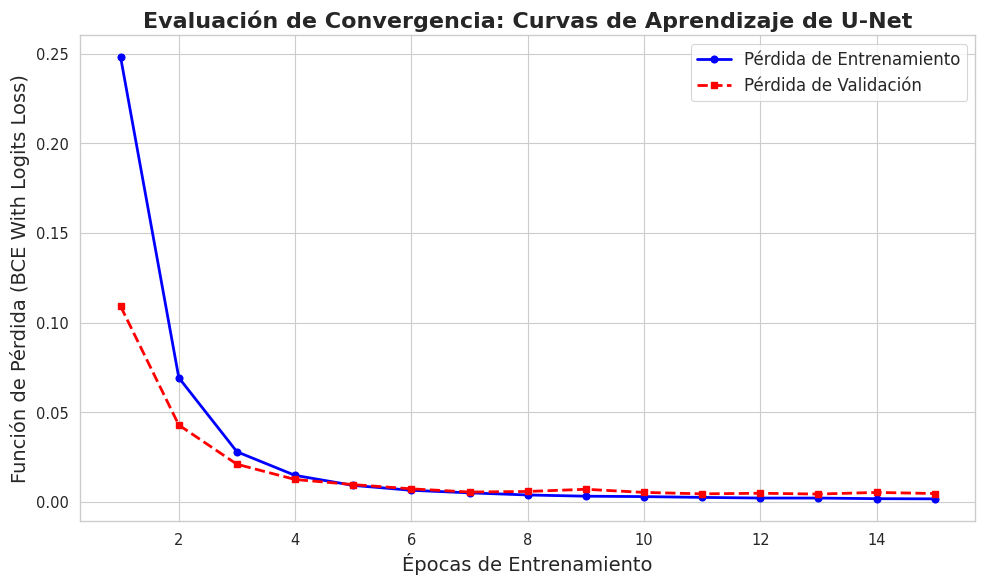

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

def graficar_curvas_de_aprendizaje(historial_entrenamiento):
    """
    Genera y guarda la gráfica de la función de pérdida durante el entrenamiento
    y validación para demostrar la capacidad de generalización del modelo.
    """
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    plt.figure(figsize=(10, 6))

    epocas = range(1, len(historial_entrenamiento['train_loss']) + 1)

    # Graficado de curvas con nombres explícitos
    plt.plot(epocas, historial_entrenamiento['train_loss'], color='blue', marker='o',
             linestyle='-', label='Pérdida de Entrenamiento', linewidth=2)
    plt.plot(epocas, historial_entrenamiento['val_loss'], color='red', marker='s',
             linestyle='--', label='Pérdida de Validación', linewidth=2)

    # Formato académico
    plt.title('Evaluación de Convergencia: Curvas de Aprendizaje de U-Net', fontsize=16, fontweight='bold')
    plt.xlabel('Épocas de Entrenamiento', fontsize=14)
    plt.ylabel('Función de Pérdida (BCE With Logits Loss)', fontsize=14)
    plt.legend(loc='upper right', fontsize=12)

    # Guardar en alta calidad para la tesis
    plt.tight_layout()
    plt.savefig('curvas_de_aprendizaje.png', dpi=300)
    plt.show()

# Ejecución (asume que la variable 'history' fue creada en la Celda 5)
graficar_curvas_de_aprendizaje(history)

# Metricas Clinicas (IoU - Dice - HD95)

In [44]:
import numpy as np
from scipy.spatial import cKDTree

def calcular_coeficiente_dice(prediccion, verdad_base, epsilon=1e-6):
    """
    Calcula el Coeficiente de Similitud de Dice (Dice Similarity Coefficient).
    Mide el grado de superposición espacial exacta entre dos áreas.
    """
    interseccion = (prediccion * verdad_base).sum()
    return (2. * interseccion + epsilon) / (prediccion.sum() + verdad_base.sum() + epsilon)

def calcular_interseccion_sobre_union(prediccion, verdad_base, epsilon=1e-6):
    """
    Calcula el Score de Intersección sobre Unión (Intersection over Union - IoU).
    """
    interseccion = (prediccion * verdad_base).sum()
    union = prediccion.sum() + verdad_base.sum() - interseccion
    return (interseccion + epsilon) / (union + epsilon)

def calcular_distancia_hausdorff_95(prediccion, verdad_base):
    """
    Calcula el percentil 95 de la Distancia de Hausdorff (HD95).
    Mide el error topológico en los bordes de la segmentación en milímetros.
    """
    coordenadas_prediccion = np.argwhere(prediccion > 0)
    coordenadas_verdad_base = np.argwhere(verdad_base > 0)

    # Si una de las dos máscaras está vacía, penalizamos con Not-A-Number
    if len(coordenadas_prediccion) == 0 or len(coordenadas_verdad_base) == 0:
        return np.nan

    arbol_verdad = cKDTree(coordenadas_verdad_base)
    distancias_pred_a_verdad, _ = arbol_verdad.query(coordenadas_prediccion)

    arbol_prediccion = cKDTree(coordenadas_prediccion)
    distancias_verdad_a_pred, _ = arbol_prediccion.query(coordenadas_verdad_base)

    todas_las_distancias = np.concatenate([distancias_pred_a_verdad, distancias_verdad_a_pred])
    return np.percentile(todas_las_distancias, 95)

# Evaluación Cuantitativa

In [46]:
import pandas as pd
import torch
from tqdm.notebook import tqdm

def compilar_tabla_de_resultados(modelo, dataloader, dispositivo, limite_batches=50):
    """
    Evalúa el modelo cuantitativamente y consolida los promedios en un DataFrame.
    """
    modelo.eval()
    resultados_individuales = []

    # Evitamos abreviaturas para el documento académico
    nombres_regiones_clinicas = [
        'Tumor Completo (Whole Tumor)',
        'Núcleo del Tumor (Tumor Core)',
        'Tejido que Realza (Enhancing Tumor)'
    ]

    print("Calculando métricas sobre el conjunto de datos de validación...")

    with torch.no_grad():
        for indice_batch, (imagenes, mascaras) in enumerate(tqdm(dataloader, desc="Evaluando Cortes Z")):
            if indice_batch >= limite_batches:
                break # Limitamos a un muestreo representativo para ahorrar tiempo

            imagenes = imagenes.to(dispositivo)

            with torch.amp.autocast('cuda'):
                logits_salida = modelo(imagenes)
                predicciones = (torch.sigmoid(logits_salida) > 0.5).float().cpu().numpy()

            mascaras_numpy = mascaras.numpy()

            # Recorrer cada imagen dentro del batch
            for b in range(predicciones.shape[0]):
                # Recorrer y medir cada región tumoral por separado
                for canal, nombre_region in enumerate(nombres_regiones_clinicas):
                    pred = predicciones[b, canal]
                    real = mascaras_numpy[b, canal]

                    # Calcular métricas solo en cortes donde existe tejido tumoral
                    if real.sum() > 0 or pred.sum() > 0:
                        dice = calcular_coeficiente_dice(pred, real)
                        iou = calcular_interseccion_sobre_union(pred, real)
                        hd95 = calcular_distancia_hausdorff_95(pred, real)

                        resultados_individuales.append({
                            'Región Tumoral': nombre_region,
                            'Coeficiente Dice': dice.item() if hasattr(dice, 'item') else dice,
                            'Score IoU': iou.item() if hasattr(iou, 'item') else iou,
                            'Distancia HD95 (mm)': hd95
                        })

    # Consolidación Estadística
    dataframe_base = pd.DataFrame(resultados_individuales)
    tabla_promedios = dataframe_base.groupby('Región Tumoral').agg({
        'Coeficiente Dice': 'mean',
        'Score IoU': 'mean',
        'Distancia HD95 (mm)': 'mean'
    }).reset_index()

    # Formateo académico a 4 decimales
    tabla_promedios['Coeficiente Dice'] = tabla_promedios['Coeficiente Dice'].map("{:.4f}".format)
    tabla_promedios['Score IoU'] = tabla_promedios['Score IoU'].map("{:.4f}".format)
    tabla_promedios['Distancia HD95 (mm)'] = tabla_promedios['Distancia HD95 (mm)'].map("{:.4f}".format)

    print("\n================================================================================")
    print("                 REPORTE FINAL DE RENDIMIENTO CLÍNICO                           ")
    print("================================================================================")
    display(tabla_promedios)

    tabla_promedios.to_csv('resultados_metrIcas_BraTS2020.csv', index=False)
    print("\n[✓] Tabla exportada como 'resultados_metrIcas_BraTS2020.csv'")

# Ejecutar la evaluación (Limitado a 50 batches para que finalice rápido en la demostración)
compilar_tabla_de_resultados(model, val_loader, device)

Calculando métricas sobre el conjunto de datos de validación...


Evaluando Cortes Z:   0%|          | 0/180 [00:00<?, ?it/s]


                 REPORTE FINAL DE RENDIMIENTO CLÍNICO                           


,Región Tumoral,Coeficiente Dice,Score IoU,Distancia HD95 (mm)
0,Núcleo del Tumor (Tumor Core),0.7598,0.6929,2.4190
1,Tejido que Realza (Enhancing Tumor),0.7486,0.6636,2.2818
2,Tumor Completo (Whole Tumor),0.7255,0.6627,4.5010



[✓] Tabla exportada como 'resultados_metrIcas_BraTS2020.csv'


# Validación Cualitativa (2 Pacientes)

Buscando 2 casos con relevancia clínica en el dataset...


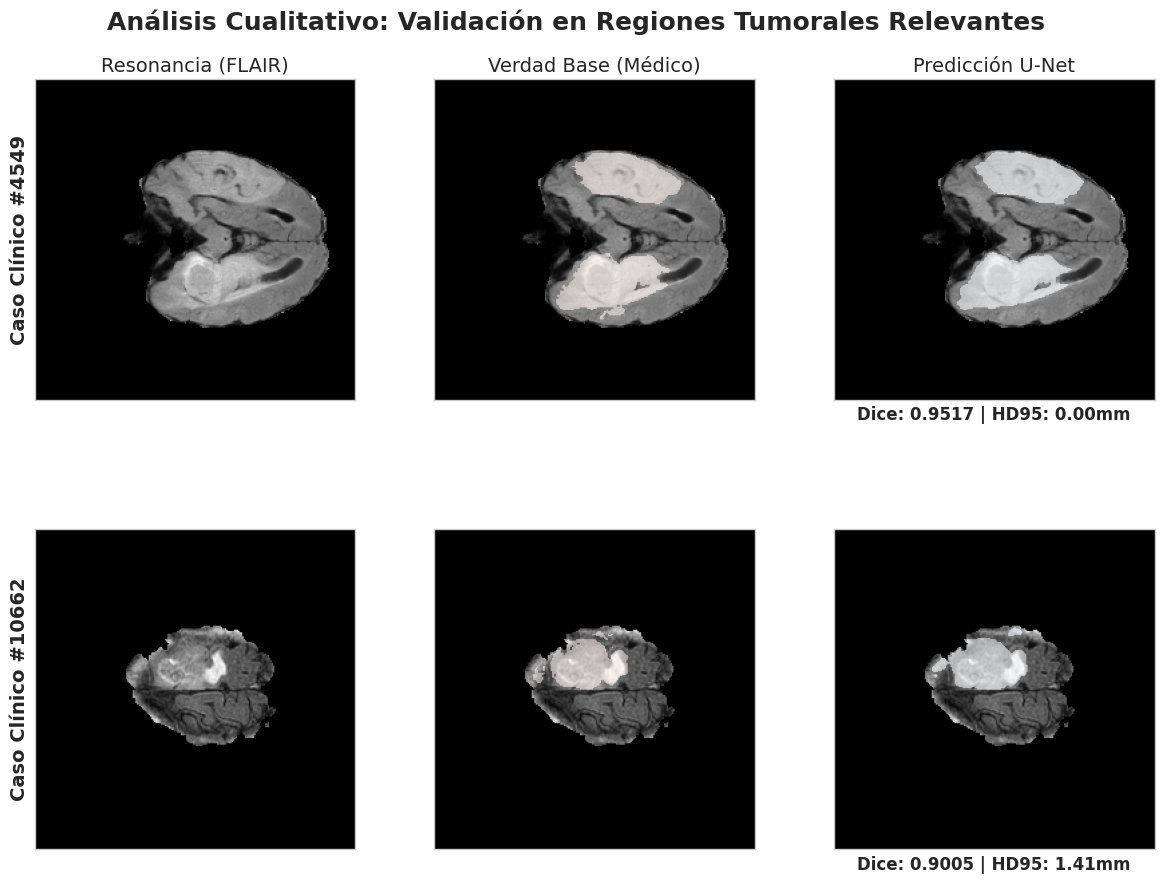

In [48]:
import random

def generar_evidencia_visual_relevante(dataset, modelo, dispositivo, cantidad_pacientes=2):
    """
    Selecciona pacientes aleatorios y busca automáticamente cortes que contengan
    tejido tumoral (relevancia clínica) para comparar la IA con la Verdad Base.
    """
    modelo.eval()
    pacientes_seleccionados = 0
    indices_explorados = set()

    # Configuración de la matriz: 2 Filas x 3 Columnas
    fig, ejes = plt.subplots(cantidad_pacientes, 3, figsize=(15, 5 * cantidad_pacientes))
    plt.subplots_adjust(hspace=0.4, wspace=0.1)

    print(f"Buscando {cantidad_pacientes} casos con relevancia clínica en el dataset...")

    while pacientes_seleccionados < cantidad_pacientes:
        # 1. Seleccionar un corte al azar
        idx = random.randint(0, len(dataset) - 1)
        if idx in indices_explorados: continue
        indices_explorados.add(idx)

        imagen_tensor, mascara_real_tensor = dataset[idx]
        mascara_real_np = mascara_real_tensor.numpy()

        # FILTRO DE RELEVANCIA: Solo aceptamos el corte si el Médico (GT) marcó tumor
        # mascara_real_np[0] es el canal de Tumor Completo (Whole Tumor)
        if mascara_real_np[0].sum() < 100: # Exigimos al menos 100 píxeles de tumor
            continue

        # 2. Inferencia del Modelo
        with torch.no_grad():
            entrada = imagen_tensor.unsqueeze(0).to(dispositivo)
            with torch.amp.autocast('cuda'):
                salida = modelo(entrada)
                prediccion = (torch.sigmoid(salida) > 0.5).float().squeeze(0).cpu().numpy()

        # 3. Preparación de Visualización
        img_flair = imagen_tensor.numpy()[0]
        verdad_base_tumor = mascara_real_np[0]
        prediccion_ia_tumor = prediccion[0]

        # Métricas individuales para el pie de foto
        dice = calcular_coeficiente_dice(prediccion_ia_tumor, verdad_base_tumor)
        hd95 = calcular_distancia_hausdorff_95(prediccion_ia_tumor, verdad_base_tumor)

        fila = pacientes_seleccionados

        # COLUMNA 1: ANATOMÍA (FLAIR)
        ejes[fila, 0].imshow(img_flair, cmap='gray')
        ejes[fila, 0].set_ylabel(f"Caso Clínico #{idx}", fontsize=14, fontweight='bold')
        if fila == 0: ejes[fila, 0].set_title("Resonancia (FLAIR)", fontsize=14)
        ejes[fila, 0].set_xticks([]); ejes[fila, 0].set_yticks([])

        # COLUMNA 2: REFERENCIA MÉDICA (GROUND TRUTH)
        ejes[fila, 1].imshow(img_flair, cmap='gray')
        ejes[fila, 1].imshow(np.ma.masked_where(verdad_base_tumor == 0, verdad_base_tumor),
                             cmap='Reds', alpha=0.5)
        if fila == 0: ejes[fila, 1].set_title("Verdad Base (Médico)", fontsize=14)
        ejes[fila, 1].set_xticks([]); ejes[fila, 1].set_yticks([])

        # COLUMNA 3: PREDICCIÓN AUTOMATIZADA (IA)
        ejes[fila, 2].imshow(img_flair, cmap='gray')
        ejes[fila, 2].imshow(np.ma.masked_where(prediccion_ia_tumor == 0, prediccion_ia_tumor),
                             cmap='Blues', alpha=0.5)
        if fila == 0: ejes[fila, 2].set_title("Predicción U-Net", fontsize=14)
        ejes[fila, 2].set_xlabel(f"Dice: {dice:.4f} | HD95: {hd95:.2f}mm", fontsize=12, fontweight='bold')
        ejes[fila, 2].set_xticks([]); ejes[fila, 2].set_yticks([])

        pacientes_seleccionados += 1

    plt.suptitle("Análisis Cualitativo: Validación en Regiones Tumorales Relevantes",
                 fontsize=18, fontweight='bold', y=0.95)
    plt.savefig('evidencia_visual_tesis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Ejecutar la galería para 2 pacientes relevantes
generar_evidencia_visual_relevante(val_dataset, model, device, cantidad_pacientes=2)

## Justificación de Métricas: Accuracy y el Desbalance de Clases

En tareas de clasificación de imágenes estándar (por ejemplo, distinguir entre perros y gatos), el *Accuracy* es una métrica confiable. Sin embargo, en la **segmentación de imágenes médicas**, utilizar el *Accuracy* es estadísticamente engañoso y clínicamente inaceptable debido al fenómeno de **Desbalance de Clases Extremo (Extreme Class Imbalance)**.

En un volumen de resonancia magnética (MRI), el tejido tumoral representa una fracción minúscula en comparación con el tejido sano y el fondo negro de la imagen (la clase mayoritaria).

**Ejemplo Analítico:**
Supongamos un corte axial típico de BraTS2020 con dimensiones de 240 x 240 píxeles:
* **Total de píxeles:** 57,600
* **Píxeles de tumor (Clase Positiva):** ~500 (menos del 1%)
* **Píxeles de tejido sano/fondo (Clase Negativa):** ~57,100

Si un modelo neuronal no aprende absolutamente nada y predice perezosamente que **toda la imagen es tejido sano (fondo negro)**, el cálculo de su métrica sería:
* Píxeles clasificados correctamente (Verdaderos Negativos): 57,100
* **Accuracy:** $57,100 / 57,600 = 99.13\%$

El modelo habría fallado por completo en detectar el tumor (un falso negativo que podría ser fatal para un paciente), pero reportaría un engañoso **99.13% de éxito**.

Por esta razón, este proyecto descarta el *Accuracy* y adopta métricas de superposición espacial que ignoran los Verdaderos Negativos (el fondo), como el **Coeficiente de Similitud de Dice (DSC)** y la **Intersección sobre Unión (IoU)**. Estas métricas penalizan severamente al modelo si no hay una predicción exacta sobre la región de interés clínica.

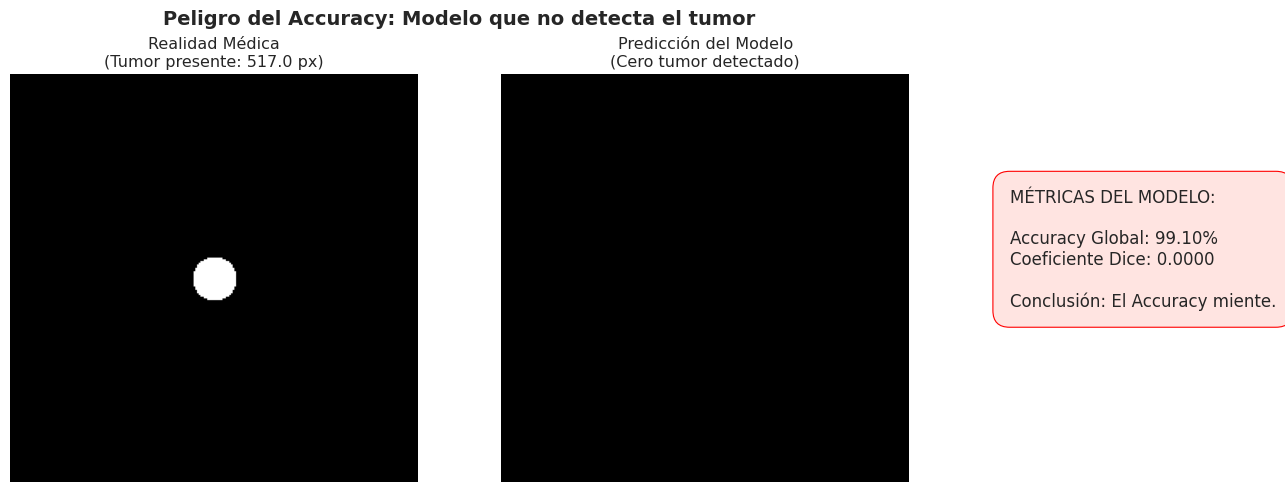

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def calcular_metricas_demostracion(prediccion, verdad_base):
    # Accuracy tradicional
    correctos = np.sum(prediccion == verdad_base)
    total = prediccion.size
    accuracy = correctos / total

    # Coeficiente de Dice
    interseccion = np.sum(prediccion * verdad_base)
    dice = (2. * interseccion) / (np.sum(prediccion) + np.sum(verdad_base) + 1e-6)

    return accuracy, dice

# 1. Crear un "Corte MRI" sintético (Fondo negro de 240x240)
verdad_base = np.zeros((240, 240))

# 2. Dibujar un "Tumor" simulado en el centro (solo 500 píxeles aprox)
for i in range(240):
    for j in range(240):
        if (i - 120)**2 + (j - 120)**2 < 13**2: # Círculo de radio 13
            verdad_base[i, j] = 1

# 3. Simular un "Modelo Perezoso" que predice que TODO es fondo (No detecta tumor)
prediccion_perezosa = np.zeros((240, 240))

# Calcular métricas
acc, dice = calcular_metricas_demostracion(prediccion_perezosa, verdad_base)

# Visualización
fig, ejes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Peligro del Accuracy: Modelo que no detecta el tumor", fontsize=14, fontweight='bold')

# Imagen Verdad Base
ejes[0].imshow(verdad_base, cmap='gray')
ejes[0].set_title(f"Realidad Médica\n(Tumor presente: {np.sum(verdad_base)} px)")
ejes[0].axis('off')

# Imagen Predicción
ejes[1].imshow(prediccion_perezosa, cmap='gray')
ejes[1].set_title(f"Predicción del Modelo\n(Cero tumor detectado)")
ejes[1].axis('off')

# Añadir cuadro de texto con el impacto estadístico
texto_metricas = (
    f"MÉTRICAS DEL MODELO:\n\n"
    f"Accuracy Global: {acc * 100:.2f}%\n"
    f"Coeficiente Dice: {dice:.4f}\n\n"
    f"Conclusión: El Accuracy miente."
)
fig.text(1.05, 0.5, texto_metricas, fontsize=12, va='center',
         bbox=dict(boxstyle="round,pad=1", facecolor='mistyrose', edgecolor='red'))

plt.tight_layout()
plt.show()